# 07 — Analýza gramatického čísla obcí -ice

Tento notebook:
1. Znovu klasifikuje `unknown` záznamy z Wikipedie vylepšeným extraktorem
2. Dořeší zbylé `unknown` lokativním fallbackem (-icích vs. -ici)
3. Vizualizuje základní statistiky (přehled, dle krajů, dle Čechy/Morava)
4. Testuje závislost na velikosti města (logistická regrese)
5. Provede statistické testy (chi² Čechy vs. Morava)
6. Vykreslí interaktivní mapu

Všechny vizualizační funkce jsou v `src/geogram/viz.py`.

In [1]:
import sys
from pathlib import Path

project_root = Path("..")
sys.path.insert(0, str(project_root / "src"))

import pandas as pd
import numpy as np

from geogram import viz, config
from geogram.wikipedia import resolve_municipality, extract_grammar_number
from tqdm.notebook import tqdm

viz.set_style()

DATA = config.PROCESSED_DIR
WIKI_CSV = DATA / "ice_grammar_wiki.csv"
OUTPUT_CSV = DATA / "ice_grammar_wiki_v2.csv"

## 1. Re-klasifikace `unknown` záznamů

Vylepšený extraktor v `wikipedia.py` přidal:
- Pattern `jsou/je + typ_obce` (město, obec, vesnice…)
- Detekci `se nacházejí` (plurál) a `se nachází` (singulár)
- Rozšířené okno pro name+verb z 80 na 150 znaků

Re-fetchujeme intro pouze pro záznamy označené `unknown` — ostatní necháváme.

In [2]:
df = pd.read_csv(WIKI_CSV)
print(f"Celkem: {len(df)} obcí")
print(df["wiki_number"].value_counts())

Celkem: 1806 obcí
wiki_number
plural      1393
singular     227
unknown      186
Name: count, dtype: int64


In [3]:
import time

SLEEP = 0.5  # Wikipedia API je benevolentní

unknown_mask = df["wiki_number"] == "unknown"
unknown_rows = df[unknown_mask].copy()
print(f"Re-klasifikuji {len(unknown_rows)} unknown záznamů...")

new_numbers = []
new_statuses = []

for _, row in tqdm(unknown_rows.iterrows(), total=len(unknown_rows)):
    try:
        intro, status = resolve_municipality(
            row["name"],
            row.get("district_name", ""),
        )
        number = extract_grammar_number(intro, row["name"])
        new_numbers.append(number)
        new_statuses.append(status)
    except Exception as e:
        new_numbers.append("error")
        new_statuses.append("error")
    time.sleep(SLEEP)

df.loc[unknown_mask, "wiki_number"] = new_numbers
df.loc[unknown_mask, "wiki_status"] = new_statuses

print("\nPo re-klasifikaci:")
print(df["wiki_number"].value_counts())

Re-klasifikuji 186 unknown záznamů...


  0%|          | 0/186 [00:00<?, ?it/s]


Po re-klasifikaci:
wiki_number
plural      1408
singular     231
unknown      167
Name: count, dtype: int64


In [4]:
df.to_csv(OUTPUT_CSV, index=False)
print(f"Uloženo: {OUTPUT_CSV}")

Uloženo: C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\data\processed\ice_grammar_wiki_v2.csv


## 1b. Lokativní fallback pro zbylé `unknown`

Ruční inspekce ukázala, že drtivá většina zbylých `unknown` má úvodní větu ve tvaru
"Obec X se nachází..." — podmětem je "obec" (vždy jednotné číslo), takže z ní
gramatické číslo samotného jména nelze určit.

Český lokativ ale číslo prozradí jinde v textu: feminina na -ice mají v plurálu
lokativ na **-icích** (např. "narozen v Chroustovicích"), v singuláru na **-ici**
(např. "v Bystřici"). Tyto tvary se objevují v těle článku (životopisy rodáků,
popis infrastruktury), ne v úvodní větě — proto stahujeme **celý článek**,
ne jen intro.

Implementováno jako `extract_grammar_number_locative()` v `wikipedia.py`.
Aplikuje se pouze na řádky, kde intro-based extraktor vrátil `unknown`.

In [5]:
from geogram.wikipedia import extract_grammar_number_locative

still_unknown_mask = df["wiki_number"] == "unknown"
still_unknown = df[still_unknown_mask].copy()
print(f"Zkouším lokativní fallback na {len(still_unknown)} zbylých unknown záznamech...")

loc_numbers = []
for _, row in tqdm(still_unknown.iterrows(), total=len(still_unknown)):
    try:
        full_text, _status = resolve_municipality(
            row["name"],
            row.get("district_name", ""),
            full_text=True,
        )
        loc_numbers.append(extract_grammar_number_locative(full_text, row["name"]))
    except Exception:
        loc_numbers.append("unknown")
    time.sleep(SLEEP)

resolved_mask = pd.Series(loc_numbers, index=still_unknown.index) != "unknown"
df.loc[still_unknown.index[resolved_mask], "wiki_number"] = [
    n for n in loc_numbers if n != "unknown"
]
df.loc[still_unknown.index[resolved_mask], "wiki_status"] = "resolved_with_locative"

print(f"\nDořešeno lokativem: {resolved_mask.sum()} / {len(still_unknown)}")
print(df["wiki_number"].value_counts())

df.to_csv(OUTPUT_CSV, index=False)
print(f"Uloženo: {OUTPUT_CSV}")

Zkouším lokativní fallback na 167 zbylých unknown záznamech...


  0%|          | 0/167 [00:00<?, ?it/s]


Dořešeno lokativem: 4 / 167
wiki_number
plural      1410
singular     233
unknown      163
Name: count, dtype: int64
Uloženo: C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\data\processed\ice_grammar_wiki_v2.csv


## 2. Přehledová statistika

In [6]:
# Pracujeme s re-klasifikovanými daty
df = pd.read_csv(OUTPUT_CSV)

classified = df[df["wiki_number"].isin(["singular", "plural"])]
n_total = len(df)
n_classified = len(classified)
n_pl = (df["wiki_number"] == "plural").sum()
n_sg = (df["wiki_number"] == "singular").sum()
n_unk = (df["wiki_number"] == "unknown").sum()

print(f"Celkový počet obcí -ice:   {n_total}")
print(f"Klasifikovaných:           {n_classified} ({n_classified/n_total:.1%})")
print(f"  Plurál:                  {n_pl} ({n_pl/n_total:.1%})")
print(f"  Singulár:                {n_sg} ({n_sg/n_total:.1%})")
print(f"Nerozpoznaných (unknown):  {n_unk} ({n_unk/n_total:.1%})")

Celkový počet obcí -ice:   1806
Klasifikovaných:           1643 (91.0%)
  Plurál:                  1410 (78.1%)
  Singulár:                233 (12.9%)
Nerozpoznaných (unknown):  163 (9.0%)


C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


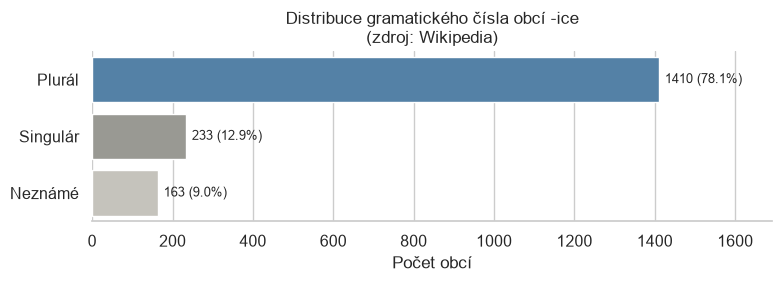

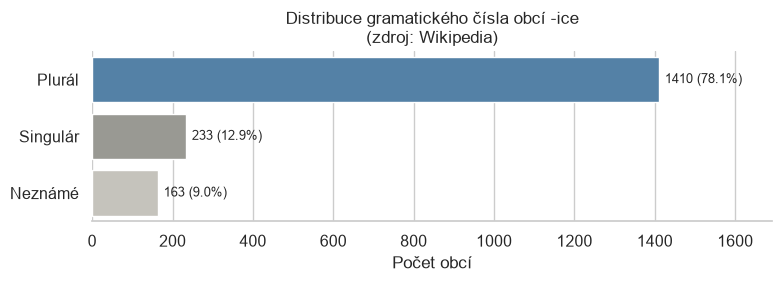

In [7]:
fig = viz.plot_overview(df)
viz.save_fig(fig, "prehled_gramaticke_cislo")
fig

## 3. Analýza nerozpoznaných obcí

Proč jsou některé obce stále `unknown`? Jsou menší než ostatní?

C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\matplotlib\scale.py:375: RuntimeWarning: overflow encountered in exp
  return np.exp(values * np.log(self.base))
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\seaborn\distributions.py:488: RuntimeWarning: invalid value encountered in subtract
  widths = inv(edges + widths) - inv(edges)
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\seaborn\distributions.py:492: RuntimeWarning: invalid value encountered in multiply
  edges = edges + (1 - shrink) / 2 * widths
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_s

Mann-Whitney U test (klasifikované vs. unknown populace):
  U = 143062, p = 0.1493
  Medián klasifikované: 469
  Medián unknown:       410


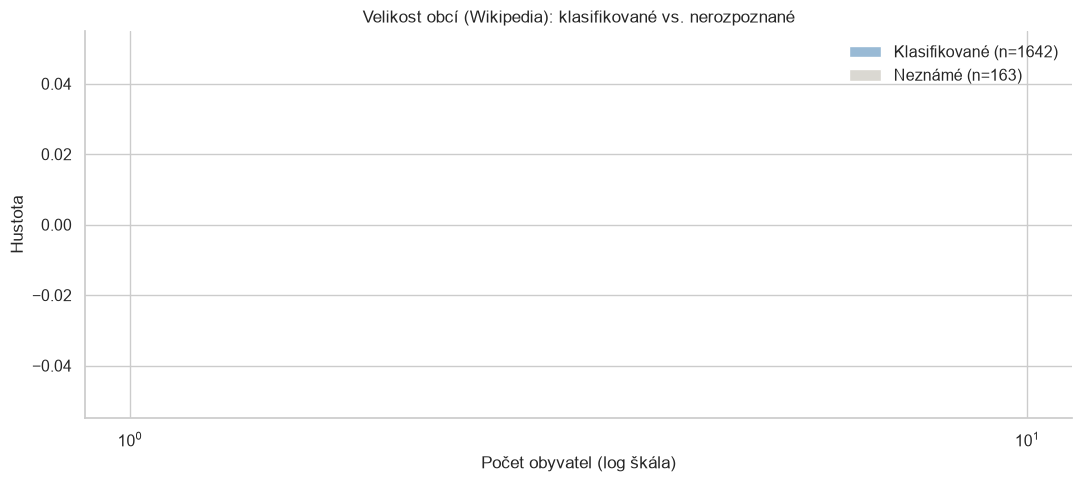

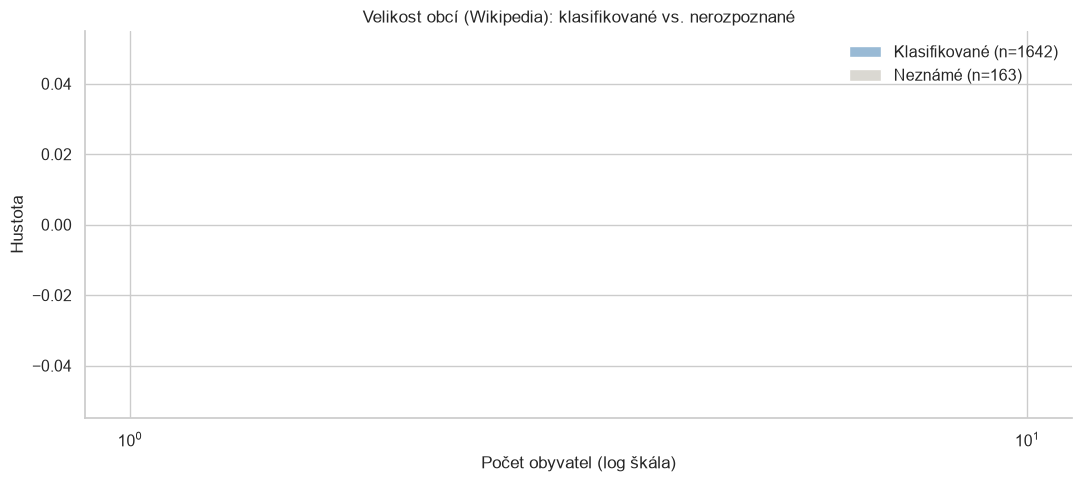

In [8]:
fig = viz.plot_missing_analysis(df)
viz.save_fig(fig, "neznama_populace")

# Statistický test: jsou unknown obce statisticky menší?
from scipy import stats

pop_class = classified["population_total"].dropna()
pop_unk = df[df["wiki_number"] == "unknown"]["population_total"].dropna()
stat, pval = stats.mannwhitneyu(pop_class, pop_unk, alternative="two-sided")
print(f"Mann-Whitney U test (klasifikované vs. unknown populace):")
print(f"  U = {stat:.0f}, p = {pval:.4f}")
print(f"  Medián klasifikované: {pop_class.median():.0f}")
print(f"  Medián unknown:       {pop_unk.median():.0f}")
fig

## 4. Regionální distribuce: kraje

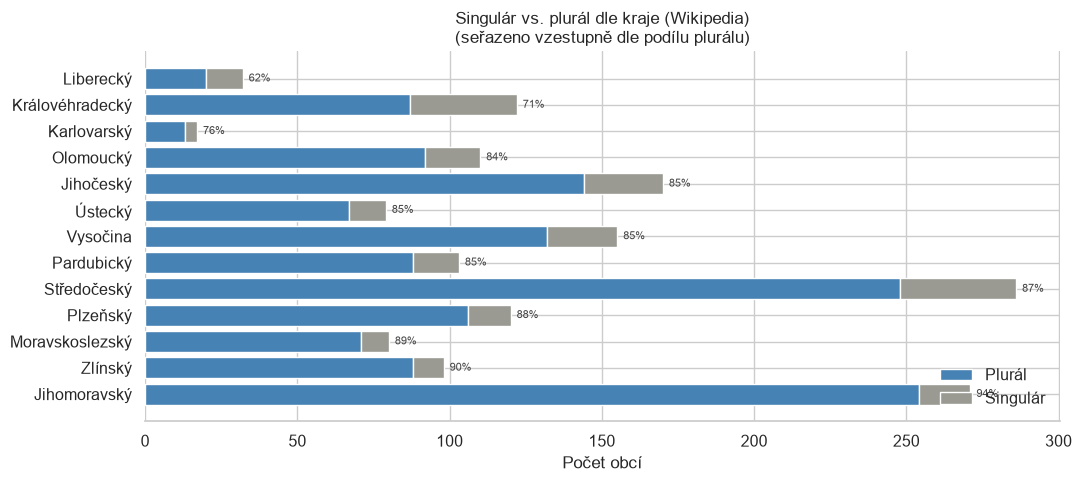

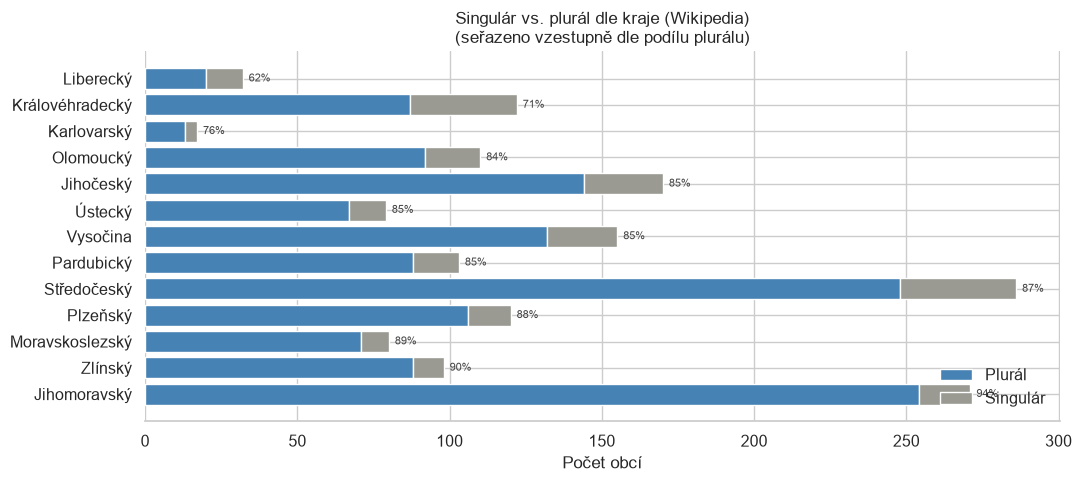

In [9]:
fig = viz.plot_by_region(df)
viz.save_fig(fig, "kraje_singular_plural")
fig

## 5. Čechy vs. Morava vs. Vysočina

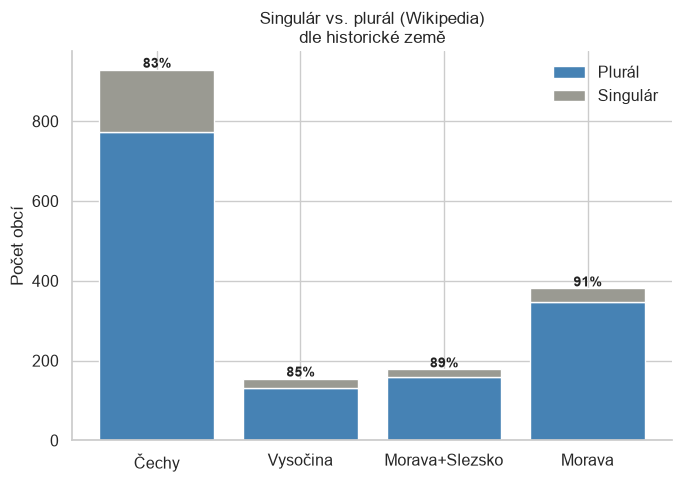

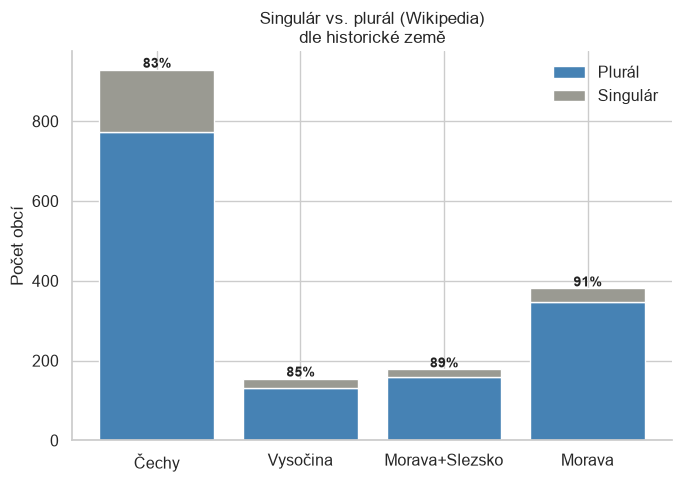

In [10]:
fig = viz.plot_by_land(df)
viz.save_fig(fig, "cechy_morava_vysocina")
fig

In [11]:
result_land = viz.chi2_land_test(df)
print("Chi² test: distribuce sg/pl vs. historická země")
print(result_land["contingency"])
print(f"\nchi² = {result_land['chi2']:.3f}")
print(f"p    = {result_land['p']:.4f}")
print(f"dof  = {result_land['dof']}")
if result_land["p"] < 0.05:
    print("→ Rozdíl je statisticky signifikantní (α=0.05)")
else:
    print("→ Rozdíl není statisticky signifikantní (α=0.05)")

Chi² test: distribuce sg/pl vs. historická země
wiki_number     plural  singular
land                            
Morava             346        35
Morava+Slezsko     159        19
Vysočina           132        23
Čechy              773       156

chi² = 14.868
p    = 0.0019
dof  = 3
→ Rozdíl je statisticky signifikantní (α=0.05)


In [12]:
result_region = viz.chi2_region_test(df)
print("Chi² test: distribuce sg/pl vs. kraj")
print(f"chi² = {result_region['chi2']:.3f}, p = {result_region['p']:.4f}, dof = {result_region['dof']}")
if result_region["p"] < 0.05:
    print("→ Statisticky signifikantní")
else:
    print("→ Není signifikantní")

Chi² test: distribuce sg/pl vs. kraj
chi² = 53.929, p = 0.0000, dof = 12
→ Statisticky signifikantní


## 6. Závislost na velikosti obce: logistická regrese

**Hypotéza:** Větší obce jsou spíše singulár (jsou historicky starší centra, jazykově standardizovaná), menší spíše plurál?

C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:292: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:292: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:40: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(path, dpi=config.DPI_SAVE, bbox_inches="tight")
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:40: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.savefig(path, dpi=config.DPI_SAVE, bbox_inches="tight")
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProje


Logistická regrese: log10(populace) → P(plurál)
                     Coef.  Std.Err.         z         P>|z|    [0.025  \
const             3.173438  0.406770  7.801554  6.114932e-15  2.376184   
population_total -0.501205  0.143978 -3.481127  4.993080e-04 -0.783396   

                    0.975]  
const             3.970693  
population_total -0.219014  


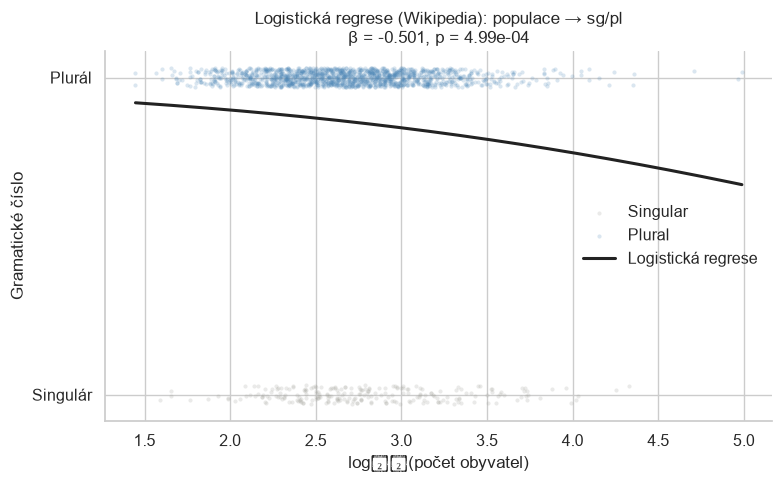

C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  func(*args, **kwargs)
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  func(*args, **kwargs)


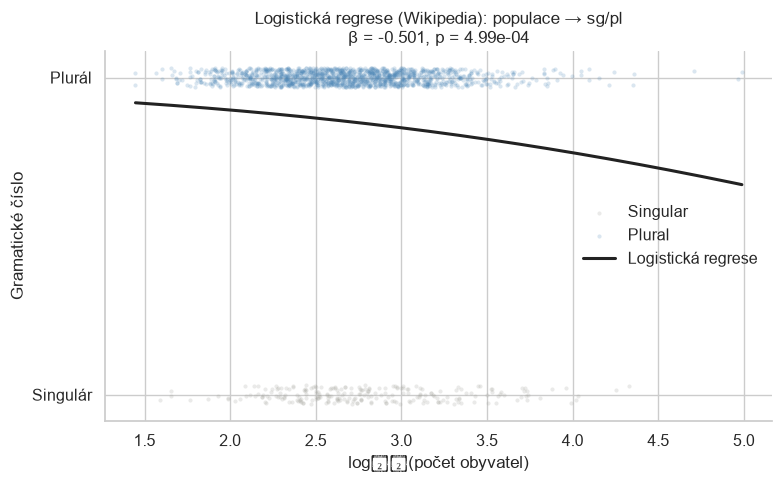

In [13]:
fig, logit_result = viz.plot_population_logistic(df, log_scale=True)
viz.save_fig(fig, "logisticka_regrese_populace")

print("\nLogistická regrese: log10(populace) → P(plurál)")
print(logit_result.summary2().tables[1])
fig

C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:319: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:324: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Singulár", "Plurál"])
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:336: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:336: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:40: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(path, dpi=config.DPI_SAVE, bbox_inc

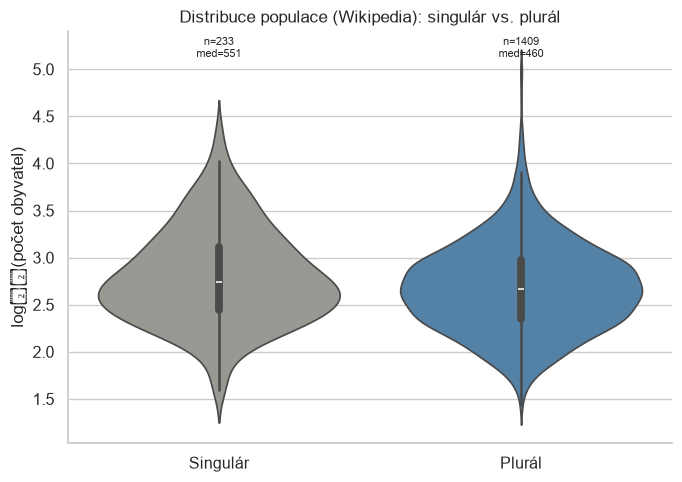

C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  func(*args, **kwargs)
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  func(*args, **kwargs)


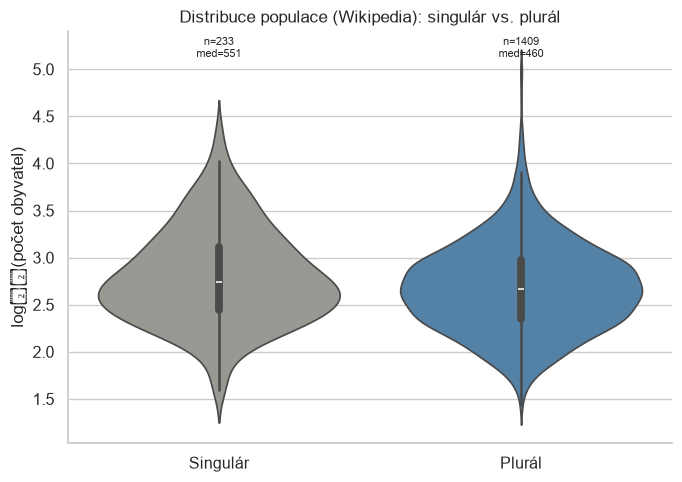

In [14]:
fig = viz.plot_population_violin(df, log_scale=True)
viz.save_fig(fig, "violin_populace_singular_plural")
fig

## 7. Souhrn výsledků

In [15]:
df_land = viz.add_land_column(df)
classified_land = df_land[df_land["wiki_number"].isin(["singular", "plural"])]

summary = (
    classified_land
    .groupby(["land", "wiki_number"])
    .size()
    .unstack(fill_value=0)
    .assign(total=lambda d: d.sum(axis=1))
    .assign(pct_plural=lambda d: d.get("plural", 0) / d["total"])
)

print("Shrnutí dle historické země:")
print(summary.to_string())

Shrnutí dle historické země:
wiki_number     plural  singular  total  pct_plural
land                                               
Morava             346        35    381    0.908136
Morava+Slezsko     159        19    178    0.893258
Vysočina           132        23    155    0.851613
Čechy              773       156    929    0.832078


## 8. Interaktivní mapa

Souřadnice pocházejí z `municipalities_ice_integrated.csv` (zdroj: RÚIAN kód obce
napojený na GitHub `33bcdd/souradnice-mest`, viz notebook 04).

In [16]:
coords = pd.read_csv(DATA / "municipalities_ice_integrated.csv")[["code", "latitude", "longitude"]]
df_map = df.merge(coords, on="code", how="left")
print(f"Obcí bez souřadnic: {df_map['latitude'].isna().sum()} / {len(df_map)}")

m = viz.plot_map_folium(df_map)
output_map = DATA / "mapa_ice.html"
m.save(output_map)
print(f"Uloženo: {output_map}")
m

Obcí bez souřadnic: 0 / 1806


Uloženo: C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\data\processed\mapa_ice.html
